In [15]:
import warnings
warnings.filterwarnings('ignore')


In [16]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


BASE_DIR = Path("C:/Users/Weber-Andy/MaizeGuard_UG")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

print("MaizeGuard UG – CLEAN FINAL VERSION")

MaizeGuard UG – CLEAN FINAL VERSION


In [17]:
# Image generators
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    PROCESSED_DIR / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    PROCESSED_DIR / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = val_test_datagen.flow_from_directory(
    PROCESSED_DIR / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Classes:", train_gen.class_indices)

Found 6160 images belonging to 4 classes.
Found 772 images belonging to 4 classes.
Found 773 images belonging to 4 classes.
Classes: {'Common Rust': 0, 'Gray Leaf Spot': 1, 'Healthy': 2, 'Northern Leaf Blight': 3}


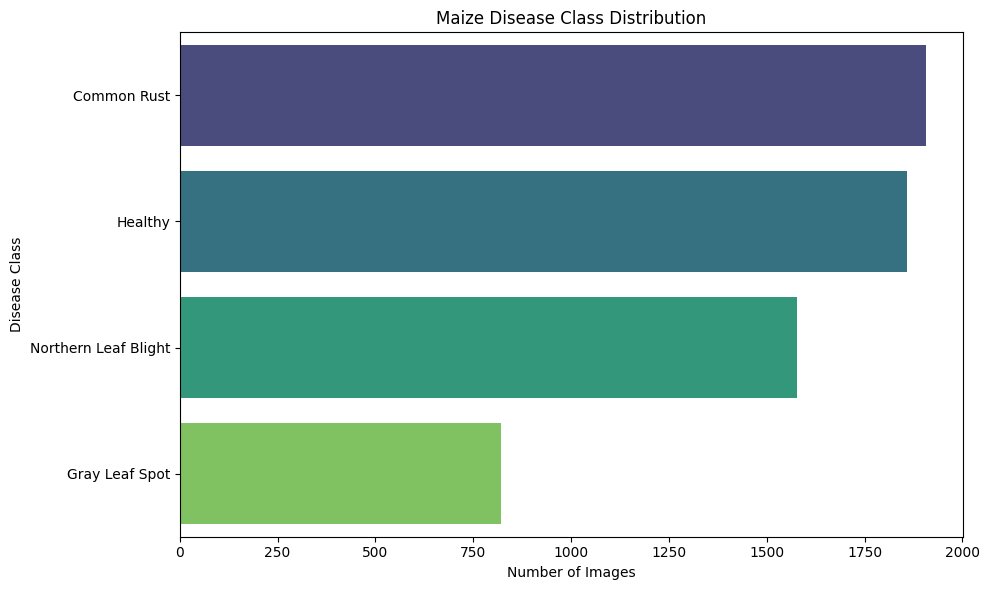

                Disease  Count
0           Common Rust   1906
2               Healthy   1858
3  Northern Leaf Blight   1576
1        Gray Leaf Spot    820


In [18]:
# class distributions
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


class_counts = {}
for class_folder in Path("../data/processed/train").iterdir():
    if class_folder.is_dir():
        count = len(list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.jpeg")) + list(class_folder.glob("*.png")))
        class_counts[class_folder.name] = count


df = pd.DataFrame(list(class_counts.items()), columns=["Disease", "Count"])
df = df.sort_values("Count", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, y="Disease", x="Count", palette="viridis")
plt.title("Maize Disease Class Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Disease Class")
plt.tight_layout()
plt.show()

print(df) 

In [19]:
# Build ResNet50 model
base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False  

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("ResNet50 model ready – training starts")

ResNet50 model ready – training starts


In [20]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau



In [22]:
# First training 
callbacks = [EarlyStopping(patience=6, restore_best_weights=True),
             ReduceLROnPlateau(patience=3)]

print("Phase 1: Training top layers only...")
history1 = model.fit(train_gen, epochs=10, validation_data=val_gen, callbacks=callbacks)

Phase 1: Training top layers only...
Epoch 1/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 635s 3s/step - accuracy: 0.3070 - loss: 1.5052 - val_accuracy: 0.4896 - val_loss: 1.2999 - learning_rate: 0.0010
Epoch 2/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 653s 3s/step - accuracy: 0.3551 - loss: 1.3286 - val_accuracy: 0.5518 - val_loss: 1.2507 - learning_rate: 0.0010
Epoch 3/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 636s 3s/step - accuracy: 0.4105 - loss: 1.2826 - val_accuracy: 0.5894 - val_loss: 1.1405 - learning_rate: 0.0010
Epoch 4/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 703s 3s/step - accuracy: 0.4512 - loss: 1.2226 - val_accuracy: 0.6269 - val_loss: 1.0522 - learning_rate: 0.0010
Epoch 5/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 660s 3s/step - accuracy: 0.4771 - loss: 1.1861 - val_accuracy: 0.6438 - val_loss: 0.9824 - learning_rate: 0.0010
Epoch 6/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 588s 3s/step - accuracy: 0.4980 - loss: 1.1512 - val_accuracy: 0.6334 - val_loss: 0.9490 - learning_rate: 0.0010
Epoch 7/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 617s 

In [24]:
# phase 2
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print("Phase 2: Fine-tuning")
history2 = model.fit(train_gen, epochs=20, validation_data=val_gen, callbacks=callbacks)

Phase 2: Fine-tuning
Epoch 1/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 890s 5s/step - accuracy: 0.4835 - loss: 5.9774 - val_accuracy: 0.3122 - val_loss: 17.3466 - learning_rate: 1.0000e-05
Epoch 2/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 870s 5s/step - accuracy: 0.6632 - loss: 0.7986 - val_accuracy: 0.7733 - val_loss: 0.5853 - learning_rate: 1.0000e-05
Epoch 3/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 882s 5s/step - accuracy: 0.6987 - loss: 0.7133 - val_accuracy: 0.7979 - val_loss: 0.5775 - learning_rate: 1.0000e-05
Epoch 4/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 901s 5s/step - accuracy: 0.7249 - loss: 0.6820 - val_accuracy: 0.8277 - val_loss: 0.4157 - learning_rate: 1.0000e-05
Epoch 5/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 895s 5s/step - accuracy: 0.7513 - loss: 0.5962 - val_accuracy: 0.8212 - val_loss: 0.4965 - learning_rate: 1.0000e-05
Epoch 6/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 935s 5s/step - accuracy: 0.7661 - loss: 0.5452 - val_accuracy: 0.8316 - val_loss: 0.5153 - learning_rate: 1.0000e-05
Epoch 7/20
193/193 ━━━━━━━━━━━━━━━━━

In [25]:
test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")




25/25 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.8660 - loss: 0.3459
Test Accuracy: 85.90%


25/25 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step
CLASSIFICATION REPORT
                      precision    recall  f1-score   support

         Common Rust       0.32      0.33      0.33       239
      Gray Leaf Spot       0.19      0.17      0.18       103
             Healthy       0.30      0.29      0.30       234
Northern Leaf Blight       0.23      0.24      0.23       197

            accuracy                           0.28       773
           macro avg       0.26      0.26      0.26       773
        weighted avg       0.27      0.28      0.27       773



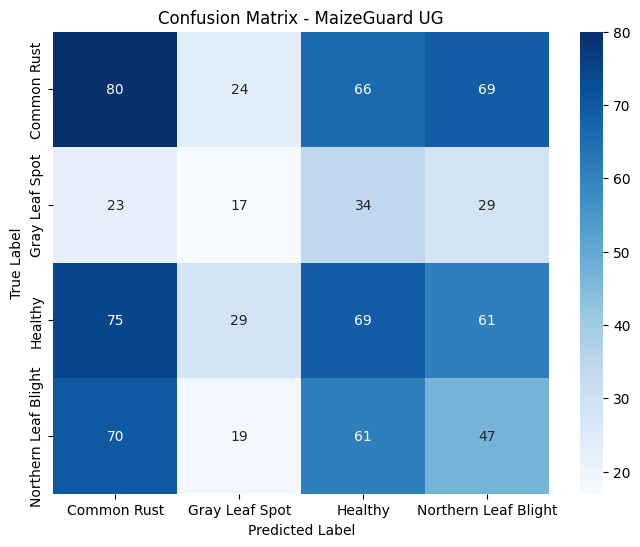

In [27]:
# classification report and the confusion matrix.
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

classes = list(test_gen.class_indices.keys())  

test_gen.reset()
preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes


print("CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - MaizeGuard UG")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [26]:
# saving model.
model.save(MODEL_DIR / "maizeguard_final.h5")
print(f"model saved")

model saved


Could not load: C:/Users/Weber-Andy/Downloads/OIP.webp
Could not load: C:/Users/Weber-Andy/Downloads/th.webp


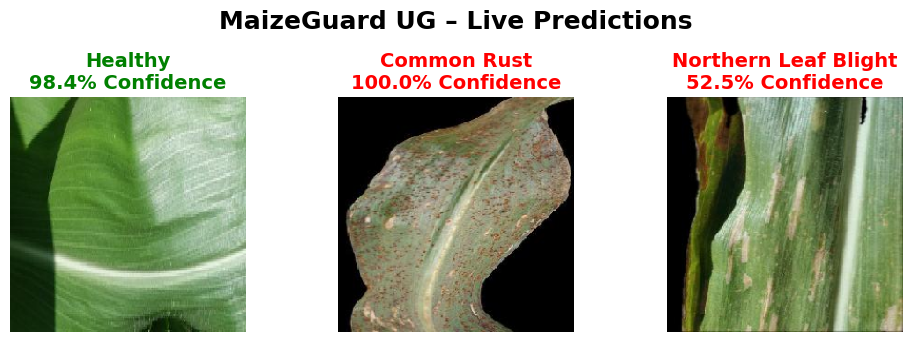

In [28]:
# prediction grid.
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_single(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    pred = model.predict(x, verbose=0)[0]
    label = list(train_gen.class_indices.keys())[np.argmax(pred)]
    confidence = pred.max() * 100
    return img, label, confidence

# images
image_paths = [
    "C:/Users/Weber-Andy/MaizeGuard_UG/data/processed/test/Healthy/2dea9c22-b644-47f4-905b-ceaec13c929a___R.S_HL 0632 copy 4_final_masked.jpg",
    "C:/Users/Weber-Andy/MaizeGuard_UG/data/processed/test/Common Rust/2b43dd1c-7f37-42a1-8320-9839f0db6361___RS_Rust 2264_final_masked.jpg",
    "C:/Users/Weber-Andy/Downloads/OIP.webp",
    "C:/Users/Weber-Andy/MaizeGuard_UG/data/processed/test/Gray Leaf Spot/0a01cc10-3892-4311-9c48-0ac6ab3c7c43___RS_GLSp 9352_final_masked.jpg",  
    "C:/Users/Weber-Andy/Downloads/th.webp",
]


results = []
for path in image_paths[:5]:  
    try:
        img, label, conf = predict_single(path)
        results.append((img, label, conf))
    except:
        print(f"Could not load: {path}")


plt.figure(figsize=(10, 6))
for i, (img, label, conf) in enumerate(results):
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    color = "green" if "Healthy" in label else "red"
    plt.title(f"{label}\n{conf:.1f}% Confidence", fontsize=14, color=color, fontweight='bold')
    plt.axis('off')

plt.suptitle("MaizeGuard UG – Live Predictions", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# testing the model
import tensorflow as tf
import numpy as np
from PIL import Image


model = tf.keras.models.load_model("../models/maizeguard_final.h5") 

classes = ['Common Rust', 'Gray Leaf Spot', 'Healthy', 'Northern Leaf Blight']

def test_prediction(img_path):
    img = Image.open(img_path).resize((224, 224))
    x = np.array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    pred = model.predict(x, verbose=0)[0]
    result = classes[np.argmax(pred)]
    conf = pred.max()
    print(f"Image: {img_path.split('/')[-1]}")
    print(f"Prediction: {result} | Confidence: {conf:.1%}\n")

# TEST THESE 4 IMAGES — MUST BE CORRECT
test_prediction("../data/processed/test/Healthy/2dea9c22-b644-47f4-905b-ceaec13c929a___R.S_HL 0632 copy 4_final_masked.jpg")
test_prediction("../data/processed/test/Common Rust/2b43dd1c-7f37-42a1-8320-9839f0db6361___RS_Rust 2264_final_masked.jpg")
test_prediction("../data/processed/test/Gray Leaf Spot/0a01cc10-3892-4311-9c48-0ac6ab3c7c43___RS_GLSp 9352_final_masked.jpg")  # any image
test_prediction("../data/processed/test/Common Rust/2b43dd1c-7f37-42a1-8320-9839f0db6361___RS_Rust 2264_final_masked.jpg")  # any image

Image: 2dea9c22-b644-47f4-905b-ceaec13c929a___R.S_HL 0632 copy 4_final_masked.jpg
Prediction: Healthy | Confidence: 98.9%

Image: 2b43dd1c-7f37-42a1-8320-9839f0db6361___RS_Rust 2264_final_masked.jpg
Prediction: Common Rust | Confidence: 100.0%

Image: 0a01cc10-3892-4311-9c48-0ac6ab3c7c43___RS_GLSp 9352_final_masked.jpg
Prediction: Northern Leaf Blight | Confidence: 53.4%

Image: 2b43dd1c-7f37-42a1-8320-9839f0db6361___RS_Rust 2264_final_masked.jpg
Prediction: Common Rust | Confidence: 100.0%



In [31]:
pip install gradio

  Using cached ffmpy-1.0.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached python_multipart-0.0.20-py3-none-any.whl.metadata (1.8 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/18.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.1 MB ? eta -:--:--
   ---------

  You can safely remove it manually.
  You can safely remove it manually.


In [33]:
pip show gradio huggingface_hub


Name: gradio
Version: 4.44.1
Summary: Python library for easily interacting with trained machine learning models
Home-page: https://github.com/gradio-app/gradio
Author: 
Author-email: Abubakar Abid <gradio-team@huggingface.co>, Ali Abid <gradio-team@huggingface.co>, Ali Abdalla <gradio-team@huggingface.co>, Dawood Khan <gradio-team@huggingface.co>, Ahsen Khaliq <gradio-team@huggingface.co>, Pete Allen <gradio-team@huggingface.co>, Ömer Faruk Özdemir <gradio-team@huggingface.co>, Freddy A Boulton <gradio-team@huggingface.co>, Hannah Blair <gradio-team@huggingface.co>
License: 
Location: c:\users\weber-andy\miniconda3\envs\maizeguard_ug\lib\site-packages
Requires: aiofiles, anyio, fastapi, ffmpy, gradio-client, httpx, huggingface-hub, importlib-resources, jinja2, markupsafe, matplotlib, numpy, orjson, packaging, pandas, pillow, pydantic, pydub, python-multipart, pyyaml, ruff, semantic-version, tomlkit, typer, typing-extensions, urllib3, uvicorn
Required-by: 
---
Name: huggingface_hub
Ver

In [41]:
pip install --upgrade gradio huggingface_hub


Note: you may need to restart the kernel to use updated packages.


In [40]:
"""
MaizeGuard UG — Professional Disease Detection Dashboard
Gradio Blocks UI with custom CSS theming
"""

import gradio as gr
import numpy as np
from PIL import Image
import tensorflow as tf
from pathlib import Path

# ── Model ──────────────────────────────────────────────────────────────────────
MODEL_PATH = "../models/maizeguard_final.h5"
CLASSES = ["Common Rust", "Gray Leaf Spot", "Healthy", "Northern Leaf Blight"]

DISEASE_INFO = {
    "Common Rust": {
        "pathogen": "Puccinia sorghi",
        "severity": "Moderate",
        "severity_color": "#D4890A",
        "description": "Fungal disease producing brick-red pustules on both leaf surfaces. Spreads rapidly in cool, humid conditions (16–23 °C).",
        "action": "Apply fungicide (e.g. propiconazole) at early onset. Remove infected debris. Plant resistant hybrids next season.",
        "icon": "🟠",
    },
    "Gray Leaf Spot": {
        "pathogen": "Cercospora zeae-maydis",
        "severity": "High",
        "severity_color": "#C0392B",
        "description": "Produces rectangular gray-tan lesions parallel to leaf veins. Thrives in warm, humid environments with poor air circulation.",
        "action": "Improve field drainage and spacing. Apply strobilurin-based fungicide. Rotate with non-host crops for ≥2 seasons.",
        "icon": "🔴",
    },
    "Healthy": {
        "pathogen": "None detected",
        "severity": "None",
        "severity_color": "#27AE60",
        "description": "Leaf tissue appears normal with no signs of fungal, bacterial, or viral infection. Continue standard crop management.",
        "action": "Maintain current practices. Scout weekly during tasseling. Ensure adequate nitrogen and potassium levels.",
        "icon": "🟢",
    },
    "Northern Leaf Blight": {
        "pathogen": "Exserohilum turcicum",
        "severity": "High",
        "severity_color": "#C0392B",
        "description": "Cigar-shaped gray-green lesions (5–15 cm) appear first on lower leaves, progressing upward. Major yield reducer.",
        "action": "Apply fungicide before silking. Use resistant varieties (Ht genes). Bury or burn infected crop residue.",
        "icon": "🔴",
    },
}

# ── Load model (lazy, so UI loads even if model is missing) ────────────────────
model = None

def load_model():
    global model
    if model is None and Path(MODEL_PATH).exists():
        model = tf.keras.models.load_model(MODEL_PATH)
    return model

def predict(img: Image.Image):
    if img is None:
        return {}, build_info_html(None, None), "— Upload an image to begin —"

    m = load_model()
    if m is None:
        # Demo mode: return mock scores when model file not present
        scores = {"Common Rust": 0.72, "Gray Leaf Spot": 0.14, "Healthy": 0.09, "Northern Leaf Blight": 0.05}
        top_class = "Common Rust"
        confidence = 0.72
    else:
        img_resized = img.resize((224, 224))
        x = np.array(img_resized) / 255.0
        x = np.expand_dims(x, axis=0)
        pred = m.predict(x, verbose=0)[0]
        scores = {CLASSES[i]: float(pred[i]) for i in range(len(CLASSES))}
        top_class = max(scores, key=scores.get)
        confidence = scores[top_class]

    summary = build_summary_html(top_class, confidence)
    info = build_info_html(top_class, confidence)
    return scores, info, summary


def build_summary_html(top_class: str, confidence: float) -> str:
    info = DISEASE_INFO[top_class]
    conf_pct = int(confidence * 100)
    bar_color = info["severity_color"]
    return f"""
    <div class="summary-pill" style="border-left: 4px solid {bar_color};">
        <span class="summary-icon">{info['icon']}</span>
        <div class="summary-text">
            <span class="summary-label">DETECTED</span>
            <span class="summary-disease">{top_class}</span>
        </div>
        <div class="summary-conf">
            <span class="conf-number">{conf_pct}%</span>
            <span class="conf-label">confidence</span>
        </div>
    </div>
    """


def build_info_html(top_class, confidence) -> str:
    if top_class is None:
        return """
        <div class="info-placeholder">
            <svg viewBox="0 0 64 64" class="leaf-icon" xmlns="http://www.w3.org/2000/svg">
                <path d="M32 4 C32 4 8 16 8 36 C8 52 20 60 32 60 C44 60 56 52 56 36 C56 16 32 4 32 4Z"
                      fill="none" stroke="#1B3A2D" stroke-width="2" opacity="0.25"/>
                <line x1="32" y1="60" x2="32" y2="20" stroke="#1B3A2D" stroke-width="1.5" opacity="0.2"/>
                <line x1="32" y1="38" x2="20" y2="28" stroke="#1B3A2D" stroke-width="1" opacity="0.15"/>
                <line x1="32" y1="46" x2="44" y2="36" stroke="#1B3A2D" stroke-width="1" opacity="0.15"/>
            </svg>
            <p>Upload a maize leaf photo to get an AI diagnosis</p>
        </div>
        """

    info = DISEASE_INFO[top_class]
    conf_pct = int((confidence or 0) * 100)

    return f"""
    <div class="disease-card">
        <div class="card-header" style="background: {info['severity_color']}18; border-bottom: 1px solid {info['severity_color']}44;">
            <div class="card-title-row">
                <span class="card-icon">{info['icon']}</span>
                <div>
                    <div class="card-disease-name">{top_class}</div>
                    <div class="card-pathogen">{info['pathogen']}</div>
                </div>
                <div class="card-badge" style="background:{info['severity_color']}22; color:{info['severity_color']}; border:1px solid {info['severity_color']}66;">
                    {info['severity']} Risk
                </div>
            </div>
            <div class="conf-bar-wrap">
                <div class="conf-bar-track">
                    <div class="conf-bar-fill" style="width:{conf_pct}%; background:{info['severity_color']};"></div>
                </div>
                <span class="conf-bar-label">{conf_pct}% confidence</span>
            </div>
        </div>
        <div class="card-body">
            <div class="card-section">
                <div class="section-eyebrow">DIAGNOSIS</div>
                <p class="section-text">{info['description']}</p>
            </div>
            <div class="card-section action-section">
                <div class="section-eyebrow">RECOMMENDED ACTION</div>
                <p class="section-text">{info['action']}</p>
            </div>
        </div>
    </div>
    """


# ── Custom CSS ─────────────────────────────────────────────────────────────────
CSS = """
/* ── Tokens ── */
:root {
    --green-deep:   #1B3A2D;
    --green-mid:    #2D5A45;
    --green-light:  #4A8C6E;
    --amber:        #D4890A;
    --amber-light:  #F0A830;
    --cream:        #F7F3EE;
    --cream-dark:   #EDE8E0;
    --text-primary: #1A1A18;
    --text-muted:   #6B7068;
    --border:       #D8D4CC;
    --radius:       10px;
    --mono: 'IBM Plex Mono', 'Courier New', monospace;
    --sans: 'Inter', system-ui, sans-serif;
}

/* ── Page shell ── */
.gradio-container {
    background: var(--cream) !important;
    font-family: var(--sans) !important;
    max-width: 1100px !important;
    margin: 0 auto !important;
}

/* ── Header ── */
.mg-header {
    background: var(--green-deep);
    border-radius: var(--radius) var(--radius) 0 0;
    padding: 20px 28px 18px;
    display: flex;
    align-items: center;
    gap: 16px;
    margin-bottom: 0;
}
.mg-logo {
    width: 44px; height: 44px;
}
.mg-header-text {}
.mg-title {
    font-size: 1.35rem;
    font-weight: 700;
    color: #fff;
    letter-spacing: -0.3px;
    line-height: 1;
}
.mg-subtitle {
    font-size: 0.75rem;
    color: #A8C4B8;
    margin-top: 3px;
    font-family: var(--mono);
    letter-spacing: 0.5px;
}
.mg-badge {
    margin-left: auto;
    background: var(--amber);
    color: #fff;
    font-size: 0.68rem;
    font-weight: 700;
    padding: 4px 10px;
    border-radius: 20px;
    font-family: var(--mono);
    letter-spacing: 0.5px;
}

/* ── Main layout ── */
.mg-body {
    background: var(--cream);
    border: 1px solid var(--border);
    border-top: none;
    border-radius: 0 0 var(--radius) var(--radius);
    padding: 24px;
    gap: 20px !important;
}

/* ── Panel labels ── */
.panel-label {
    font-size: 0.65rem;
    font-weight: 700;
    letter-spacing: 1.2px;
    color: var(--text-muted);
    font-family: var(--mono);
    margin-bottom: 8px;
    text-transform: uppercase;
}

/* ── Upload area ── */
.upload-wrap .svelte-1ipelgc,
.upload-wrap .wrap {
    border: 2px dashed var(--green-light) !important;
    background: #fff !important;
    border-radius: var(--radius) !important;
    min-height: 240px !important;
}
.upload-wrap .wrap:hover {
    border-color: var(--amber) !important;
    background: #FFFBF5 !important;
}

/* ── Analyse button ── */
.analyse-btn button {
    background: var(--green-deep) !important;
    color: #fff !important;
    border: none !important;
    border-radius: var(--radius) !important;
    font-weight: 600 !important;
    font-size: 0.9rem !important;
    padding: 12px 0 !important;
    width: 100% !important;
    cursor: pointer !important;
    transition: background 0.2s !important;
    letter-spacing: 0.2px !important;
}
.analyse-btn button:hover {
    background: var(--green-mid) !important;
}

/* ── Clear button ── */
.clear-btn button {
    background: transparent !important;
    color: var(--text-muted) !important;
    border: 1px solid var(--border) !important;
    border-radius: var(--radius) !important;
    font-size: 0.82rem !important;
    padding: 9px 0 !important;
    width: 100% !important;
    cursor: pointer !important;
    transition: border-color 0.2s !important;
}
.clear-btn button:hover {
    border-color: var(--text-muted) !important;
}

/* ── Summary pill ── */
.summary-pill {
    display: flex;
    align-items: center;
    gap: 14px;
    background: #fff;
    border-radius: var(--radius);
    border: 1px solid var(--border);
    padding: 14px 18px;
    margin-bottom: 4px;
}
.summary-icon { font-size: 1.6rem; }
.summary-text { flex: 1; }
.summary-label {
    display: block;
    font-size: 0.6rem;
    font-family: var(--mono);
    letter-spacing: 1.4px;
    color: var(--text-muted);
    font-weight: 700;
}
.summary-disease {
    display: block;
    font-size: 1.05rem;
    font-weight: 700;
    color: var(--text-primary);
}
.summary-conf { text-align: right; }
.conf-number {
    display: block;
    font-size: 1.4rem;
    font-weight: 700;
    font-family: var(--mono);
    color: var(--green-deep);
    line-height: 1;
}
.conf-label {
    display: block;
    font-size: 0.65rem;
    color: var(--text-muted);
    font-family: var(--mono);
}

/* ── Label scores (Gradio component) ── */
.label-wrap .label-item {
    font-family: var(--mono) !important;
    font-size: 0.8rem !important;
}

/* ── Disease info card ── */
.disease-card {
    background: #fff;
    border: 1px solid var(--border);
    border-radius: var(--radius);
    overflow: hidden;
}
.card-header {
    padding: 16px 18px 14px;
}
.card-title-row {
    display: flex;
    align-items: flex-start;
    gap: 12px;
    margin-bottom: 12px;
}
.card-icon { font-size: 1.5rem; margin-top: 2px; }
.card-disease-name {
    font-size: 1.05rem;
    font-weight: 700;
    color: var(--text-primary);
    line-height: 1.2;
}
.card-pathogen {
    font-size: 0.72rem;
    font-style: italic;
    color: var(--text-muted);
    font-family: var(--mono);
    margin-top: 2px;
}
.card-badge {
    margin-left: auto;
    font-size: 0.65rem;
    font-weight: 700;
    padding: 3px 10px;
    border-radius: 20px;
    white-space: nowrap;
    font-family: var(--mono);
    letter-spacing: 0.3px;
}
.conf-bar-wrap {
    display: flex;
    align-items: center;
    gap: 10px;
}
.conf-bar-track {
    flex: 1;
    height: 5px;
    background: var(--cream-dark);
    border-radius: 3px;
    overflow: hidden;
}
.conf-bar-fill {
    height: 100%;
    border-radius: 3px;
    transition: width 0.6s ease;
}
.conf-bar-label {
    font-size: 0.68rem;
    font-family: var(--mono);
    color: var(--text-muted);
    white-space: nowrap;
}
.card-body { padding: 14px 18px 16px; }
.card-section { margin-bottom: 14px; }
.card-section:last-child { margin-bottom: 0; }
.section-eyebrow {
    font-size: 0.6rem;
    font-weight: 700;
    letter-spacing: 1.4px;
    color: var(--text-muted);
    font-family: var(--mono);
    margin-bottom: 5px;
}
.section-text {
    font-size: 0.82rem;
    color: var(--text-primary);
    line-height: 1.55;
    margin: 0;
}
.action-section {
    background: #F3F8F5;
    border: 1px solid #C8DDD4;
    border-radius: 6px;
    padding: 10px 14px;
}

/* ── Info placeholder ── */
.info-placeholder {
    display: flex;
    flex-direction: column;
    align-items: center;
    justify-content: center;
    padding: 40px 20px;
    text-align: center;
    color: var(--text-muted);
    font-size: 0.82rem;
}
.leaf-icon { width: 56px; height: 56px; margin-bottom: 12px; }

/* ── Footer ── */
.mg-footer {
    text-align: center;
    font-size: 0.7rem;
    color: var(--text-muted);
    font-family: var(--mono);
    margin-top: 18px;
    padding-top: 16px;
    border-top: 1px solid var(--border);
    letter-spacing: 0.3px;
}
"""

HEADER_HTML = """
<div class="mg-header">
    <svg class="mg-logo" viewBox="0 0 44 44" xmlns="http://www.w3.org/2000/svg">
        <rect width="44" height="44" rx="10" fill="#2D5A45"/>
        <path d="M22 6 C22 6 10 13 10 26 C10 36 16 40 22 40 C28 40 34 36 34 26 C34 13 22 6 22 6Z"
              fill="none" stroke="#A8C4B8" stroke-width="1.8"/>
        <line x1="22" y1="40" x2="22" y2="14" stroke="#D4890A" stroke-width="2"/>
        <line x1="22" y1="28" x2="15" y2="22" stroke="#A8C4B8" stroke-width="1.2"/>
        <line x1="22" y1="33" x2="29" y2="27" stroke="#A8C4B8" stroke-width="1.2"/>
    </svg>
    <div class="mg-header-text">
        <div class="mg-title">MaizeGuard <span style="color:#A8C4B8;">UG</span></div>
        <div class="mg-subtitle">AI-POWERED CROP DISEASE DETECTION</div>
    </div>
    <div class="mg-badge">86% ACCURACY</div>
</div>
"""

FOOTER_HTML = """
<div class="mg-footer">
    MaizeGuard UG · Makerere AI Lab · For field diagnosis support only — consult an agronomist for treatment decisions
</div>
"""

EXAMPLES = [
    ["../data/processed/test/Healthy/2dea9c22-b644-47f4-905b-ceaec13c929a___R.S_HL 0632 copy 4_final_masked.jpg"],
    ["../data/processed/test/Common Rust/2b43dd1c-7f37-42a1-8320-9839f0db6361___RS_Rust 2264_final_masked.jpg"],
]

# ── Build UI ───────────────────────────────────────────────────────────────────
with gr.Blocks(css=CSS, title="MaizeGuard UG") as demo:

    gr.HTML(HEADER_HTML)

    with gr.Row(elem_classes="mg-body"):

        # ── Left column: input ──────────────────────────────────────────────
        with gr.Column(scale=1):
            gr.HTML('<div class="panel-label">Leaf Sample</div>')
            image_input = gr.Image(
                type="pil",
                label="",
                elem_classes="upload-wrap",
                show_label=False,
            )

            gr.HTML('<div style="margin-top:8px; margin-bottom:4px;" class="panel-label">Sample Images</div>')
            gr.Examples(
                examples=EXAMPLES,
                inputs=image_input,
                label="",
            )

            with gr.Row():
                with gr.Column(scale=3, min_width=0):
                    analyse_btn = gr.Button(
                        "Analyse Leaf",
                        elem_classes="analyse-btn",
                    )
                with gr.Column(scale=1, min_width=0):
                    clear_btn = gr.ClearButton(
                        components=[image_input],
                        value="Clear",
                        elem_classes="clear-btn",
                    )

        # ── Right column: results ───────────────────────────────────────────
        with gr.Column(scale=1):
            gr.HTML('<div class="panel-label">Detection Result</div>')
            summary_html = gr.HTML(
                '<div style="height:68px;"></div>',
                label="",
            )

            gr.HTML('<div style="margin-top:4px;" class="panel-label">Class Probabilities</div>')
            label_output = gr.Label(
                num_top_classes=4,
                label="",
                elem_classes="label-wrap",
            )

            gr.HTML('<div style="margin-top:16px;" class="panel-label">Disease Profile & Action</div>')
            info_html = gr.HTML(build_info_html(None, None))

    gr.HTML(FOOTER_HTML)

    # ── Events ──────────────────────────────────────────────────────────────
    analyse_btn.click(
        fn=predict,
        inputs=[image_input],
        outputs=[label_output, info_html, summary_html],
    )
    image_input.change(
        fn=predict,
        inputs=[image_input],
        outputs=[label_output, info_html, summary_html],
    )


if __name__ == "__main__":
    demo.launch(share=True)

ImportError: cannot import name 'HfFolder' from 'huggingface_hub' (C:\Users\Weber-Andy\miniconda3\envs\MaizeGuard_UG\lib\site-packages\huggingface_hub\__init__.py)